In [1]:
from objects.FreeGroup import *
from objects.WhiteheadGraph import *
import graph_tool as gt
from graph_tool.draw import sfdp_layout, graph_draw

/nix/store/gdyl89d3lgffvxb3qjqlh91m12x8lifr-python3-3.13.12-env/lib/python3.13/site-packages/graph_tool/draw/cairo_draw.py:1553: RuntimeWarning: Error importing Gtk module: ; GTK+ drawing will not work.
  warnings.warn(msg, RuntimeWarning)


In [2]:
p = word("a^3 b")

In [32]:
p.word + (p.word[0],)

(a³, b, a³)

In [33]:
ug = gt.Graph(directed=False)
ug.set_fast_edge_lookup(fast=True)

lookup : dict[Elem, int] = {}
lookup[Elem("a", 1)] = 0
lookup[Elem("a", -1)] = 1
lookup[Elem("b", -1)] = 2
lookup[Elem("b", 1)] = 3

edge_list = [(lookup[Elem("a", 1)], lookup[Elem("a", -1)], 2), 
             (lookup[Elem("a", 1)], lookup[Elem("b", -1)], 1), 
             (lookup[Elem("b", 1)], lookup[Elem("a", -1)], 1)]
print(edge_list)

weight = ug.new_ep("int")
ug.ep["weight"] = weight
ug.add_edge_list(edge_list, eprops=[weight])

elem_arr = [Elem("a", 1), Elem("a", -1), Elem("b", -1), Elem("b", 1)]

elements = ug.new_vp("object")
for v in ug.vertices():
    elements[v] = elem_arr[int(v)]
ug.vp["elem"] = elements

[(0, 1, 2), (0, 2, 1), (3, 1, 1)]


In [7]:
ug = make_whitehead_graph(word("a b c^2 d a"))

<VertexPropertyMap object with value type 'python::object', for Graph 0x71595b7efed0, at 0x71595ae9f700>


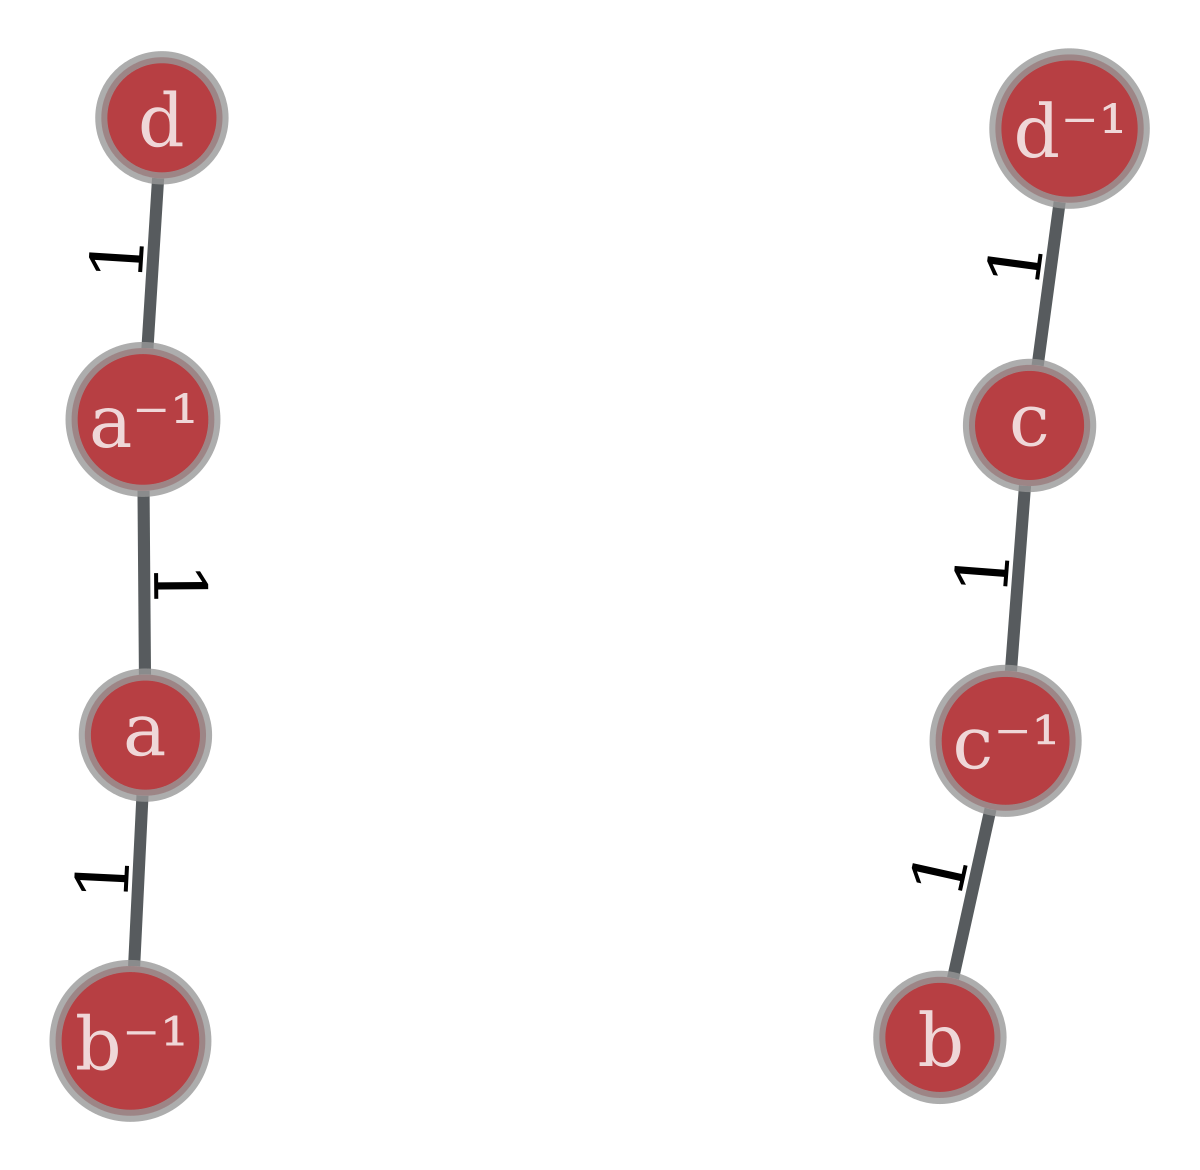

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x71595b7efed0, at 0x71595ae9f930>

In [8]:
weight = ug.edge_properties["weight"]
elem = ug.vertex_properties["elem"]
v_text = ug.new_vertex_property("string")
for v in ug.vertices():
    v_text[v] = str(elem[v])
print(elem)
pos = sfdp_layout(ug, eweight=weight)
graph_draw(ug, edge_text=weight, pos=pos, vertex_text=v_text)

In [29]:
get_edge_list(word("a^3 b"))

({a: 0, a⁻¹: 1, b⁻¹: 2, b: 3}, [(0, 1, 2), (0, 2, 1), (3, 1, 1)])

In [26]:
(1, 4)[::-1]

(4, 1)